In [65]:
import numpy as np
from numba import jit, njit, prange, float64, int32
from tqdm import tqdm

pSun = lambda W: 0.5 if W==0 else 0.9
pBad = lambda W: 0.5 if W==0 else 0.1

nDays = 100000

Sun  = np.zeros(nDays)
Bad  = np.ones( nDays)
Days = np.zeros(nDays)
W = 1 # 1 == Sun, -1 == Bad
for i in tqdm(range(nDays)):
    W = np.random.choice([1, 0], p=[pSun(W), pBad(W)])
    Days[i] = W

@njit(float64[:](float64[:]))
def pGood(Days):
    return np.cumsum(Days)/np.arange(1, len(Days)+1, 1) ### it's much faster like this.
    #np.array([np.sum(Days[:n])/(n+1) for n in prange(nDays)], dtype=np.float64)

@njit(float64[:](float64[:]))
def pBad(Days):
    return np.cumsum(1-Days)/np.arange(1, len(Days)+1, 1) ### it's much faster like this.
    #np.array([-np.sum(Days[:n]-1)/(n+1) for n in prange(nDays)], dtype=np.float64)

Good = pGood(Days)
Bad  = pBad (Days)
print('Done Loading!')

### I'd like to add the autocorrelation time with emcee but it does not work... "chain is too short".

import arviz as az

tauGood = int( az.ess(Good[1:], method='median'))
tauBad  = int( az.ess(Bad [1:], method='median'))
# import emcee
# tauGood = int( emcee.autocorr.integrated_time(Good[nCut:]) ) ### The Chain is TOO short, sorry!
# tauBad  = int( emcee.autocorr.integrated_time(Bad [nCut:]) ) ### The Chain is TOO short, sorry!

tGood = Good[nCut::tauGood]
tBad  = Bad [nCut::tauBad ]

print('Autocorrelation Times Ready!')

100%|███████████████████████████████████████████████████████████████████████| 100000/100000 [00:01<00:00, 61474.83it/s]


Done Loading!
Autocorrelation Times Ready!


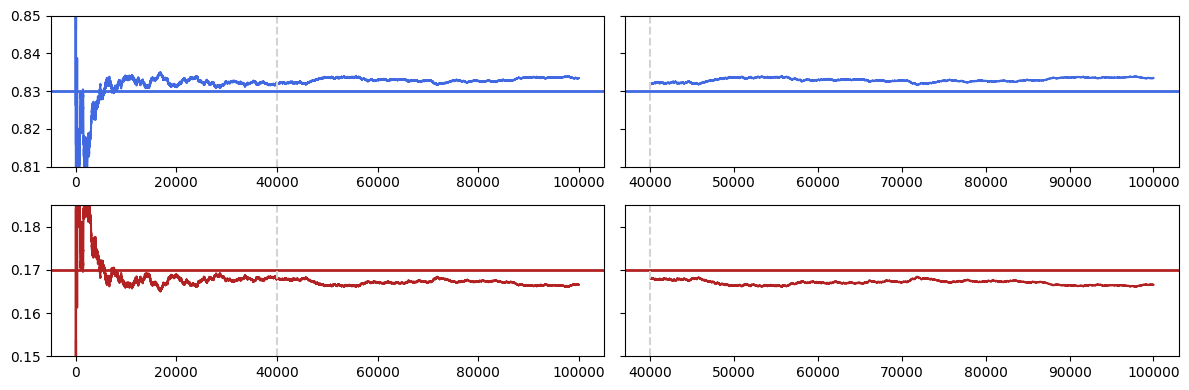

In [68]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, axs = plt.subplots(2, 2, figsize=(12, 4), tight_layout=True, sharey='row', width_ratios=[0.5, 0.5]) 
nCut=40000

axs[0, 0].plot(np.arange(nDays),                 Good, c='royalblue')
axs[0, 1].plot(np.arange(nDays)[nCut::tauGood], tGood, c='royalblue')

for ax in [ axs[0, 0], axs[0, 1] ]:
    ax.axhline(0.83, lw=2, c='royalblue')
 
axs[0, 0].set_ylim(0.81, 0.85)

axs[1, 0].plot(np.arange(nDays),                 Bad , c='firebrick')
axs[1, 1].plot(np.arange(nDays)[nCut::tauBad ], tBad , c='firebrick')

for ax in [ axs[1, 0], axs[1, 1] ]:  
    ax.axhline(0.17, lw=2, c='firebrick')

axs[1, 0].set_ylim(0.15, 0.185)

for ax in axs.flatten(): 
    ax.axvline(nCut, ls='--', c='lightgray')

Before Cut : median & sigmaG
Good : 0.8326934 & 0.0008954
Bad  : 0.1673066 & 0.0008954
After Cut  : median & sigmaG
Good : 0.8328839 & 0.0006692
Bad  : 0.1671161 & 0.0006692


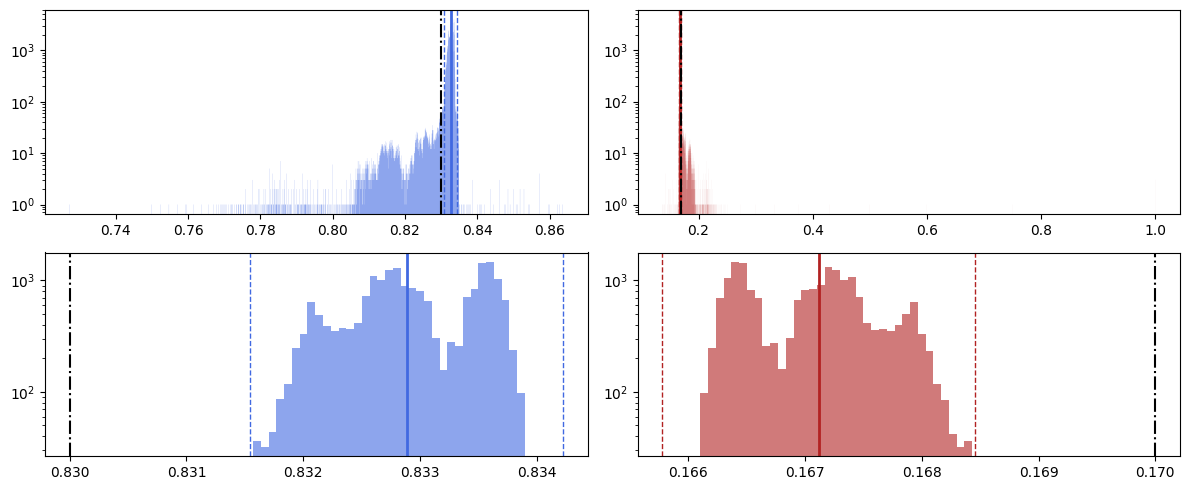

In [69]:
### Add statistics of the distribution: mean, rms, etc.

from astropy.visualization import hist

fig, axs = plt.subplots(2, 2, figsize=(12, 5), tight_layout=True, sharex=False)

kwargs = {'bins':'freedman', 'histtype':'stepfilled', 'facecolor':'royalblue', 'alpha':0.6, 'density':False}
_ = hist( Good[10::1], ax=axs[0, 0], **kwargs) ### for the SOLE purpose of better visualizing this histogram, I do this [10: ] thing.
_ = hist(tGood,        ax=axs[1, 0], **kwargs)

kwargs = {'bins':'freedman', 'histtype':'stepfilled', 'facecolor':'firebrick', 'alpha':0.6, 'density':False}
_ = hist( Bad [  ::1], ax=axs[0, 1], **kwargs)
_ = hist(tBad,         ax=axs[1, 1], **kwargs)

for ax in axs.flatten(): 
    ax.set_yscale('log')

Chains = [[Good, tGood], ### The stats are computed on the full chain!
          [Bad , tBad ]]
Colors = [['royalblue' for _ in range(2)],
          ['firebrick' for _ in range(2)]]

Truth  = [[0.83, 0.83], 
          [0.17, 0.17]]
from astroML.stats import sigmaG

i = 0; j=0;
for j in range(2):
    if j == 0: print('Before Cut : median & sigmaG')
    if j == 1: print('After Cut  : median & sigmaG')
    for i in range(2):
        if i == 0: W = 'Good'
        if i == 1: W = 'Bad'
        y  = np.median(Chains[i][j])
        sG = sigmaG(Chains[i][j]) 
        s  = np.var(Chains[i][j])**0.5
        print('{0:5}: {1:.7f} & {2:.7f}'.format(W, y, sG))
        axs[j, i].axvline(y     , lw=2, alpha=1.0, zorder=1, c=Colors[i][j], ls='-')
        axs[j, i].axvline(y-2*sG, lw=1, alpha=1.0, zorder=1, c=Colors[i][j], ls='--')
        axs[j, i].axvline(y+2*sG, lw=1, alpha=1.0, zorder=1, c=Colors[i][j], ls='--')
        # axs[j, i].axvline(y-3*s , lw=1, alpha=1.0, zorder=1, c=Colors[i][j], ls=':')
        # axs[j, i].axvline(y+3*s , lw=1, alpha=1.0, zorder=1, c=Colors[i][j], ls=':')
        axs[j, i].axvline(Truth[i][j], alpha=1, zorder=1, c='k', ls='-.')

The distribution is very compact around its median value, and the predicted result sits within two $\sigma_{G}$ from the sample median.

I chose to use $\sigma_{G}$ rather than the sample standard deviation, $s$, as the chain doesn't really look like a gaussian distribution.

In that case, I checked that the predicted value would be within $3 s$ from the median.

The chain, however, seems to be stabilizing on a value which is NOT the one I am expectingto get. This may be due to my chain being too short or thinned wrongly, or the "actual" value may not be 0.83 or 0.17.